In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
min_fibers = 100

In [4]:
main_dir = '/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve'
tmp = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_basic.fits'), columns=['TARGETID']))
tmp1 = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_pixel.fits')))
tmp2 = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_lrgmask_v1.1.fits.gz')))
lrg = hstack([tmp, tmp1, tmp2])

In [5]:
target_bit = 0  # LRG
fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/zcatalog/ztile-main-dark-cumulative.fits'
cat = Table(fitsio.read(fn, columns=['DESI_TARGET']))
idx = np.where(cat['DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat), len(np.unique(cat['TARGETID'])))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'lrg_mask']], keys='TARGETID')
print(len(cat), len(np.unique(cat['TARGETID'])))

2959857 2873980
2959857 2873980


In [6]:
cat['MEAN_X'], cat['MEAN_Y'] = 0., 0.
for fiber in np.unique(cat['FIBER']):
    mask = cat['FIBER']==fiber
    cat['MEAN_X'][mask] = np.mean(cat['FIBERASSIGN_X'][mask])
    cat['MEAN_Y'][mask] = np.mean(cat['FIBERASSIGN_Y'][mask])

In [7]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as STARs
mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# PIXEL_NOBS consistency cut
min_nobs = 1
mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()

# mask = cat['EBV']<0.1
# print(np.sum(mask)/len(mask))
# cat = cat[mask]
# print(len(cat))

print(len(cat))

FIBERSTATUS    72451 2887406 0.02447787173501963
No data    0 2887406 0.0
LRG mask 2623620 263786 0.09135743293461328
Remove QSO targets 2596835 26785 0.010209176633811299
Remove objects classified as QSOs: 2550933 45902 0.01767613267689322
Remove objects classified as STARs: 2541951 8982 0.003521064645759022
Min depth    123813 2418138 0.048707862582716976
NOBS 2416528 1610 0.9993341984617917
0.011732949090596094
2416528


In [8]:
cat['Z'].max()

1.6978745545231095

In [14]:
cat.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

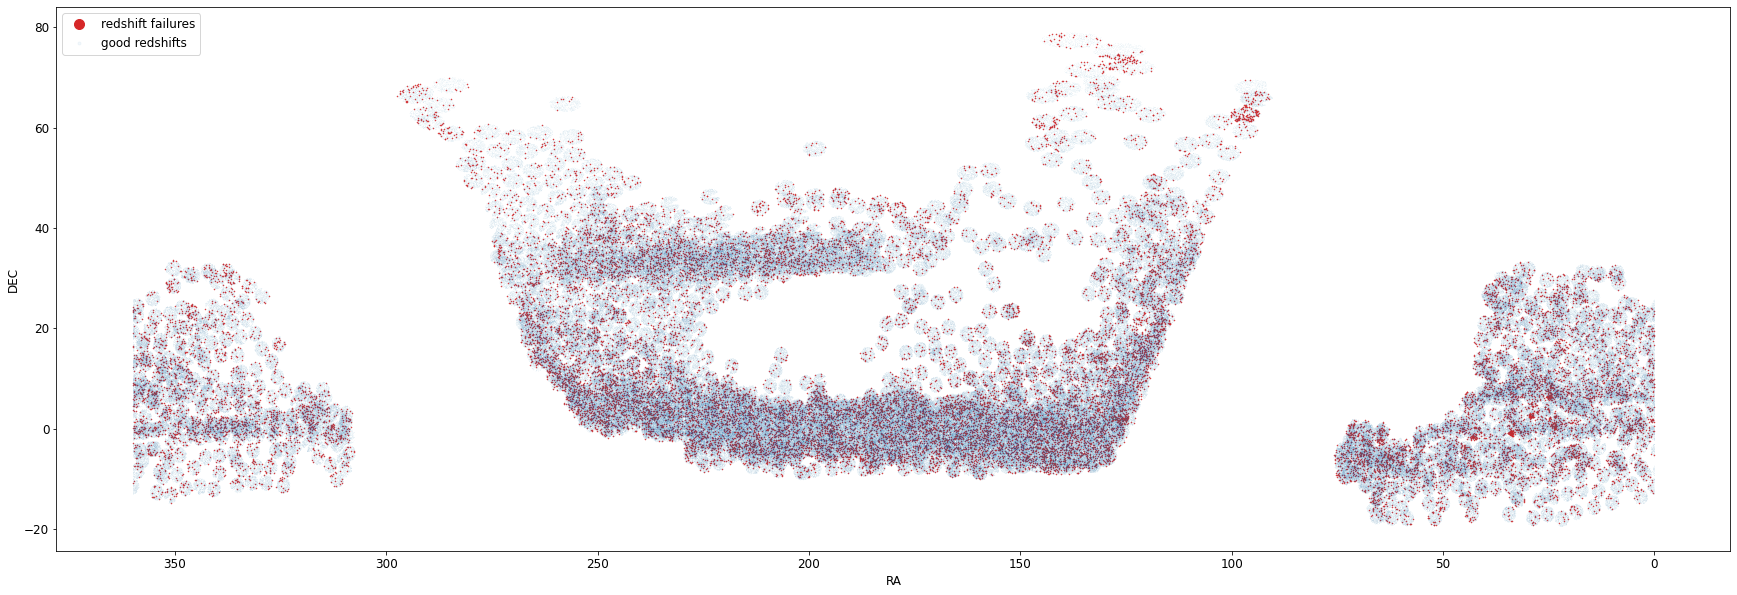

In [15]:
plt.figure(figsize=(30, 10))
plt.plot(cat['RA'][~cat['q']], cat['DEC'][~cat['q']], 'C3.', ms=1, label='redshift failures')
plt.plot(cat['RA'][cat['q']], cat['DEC'][cat['q']], 'C0.', ms=.3, alpha=0.05, label='good redshifts')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper left', markerscale=20)
# plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

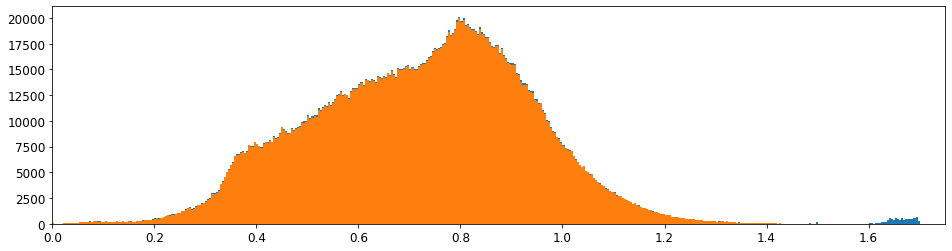

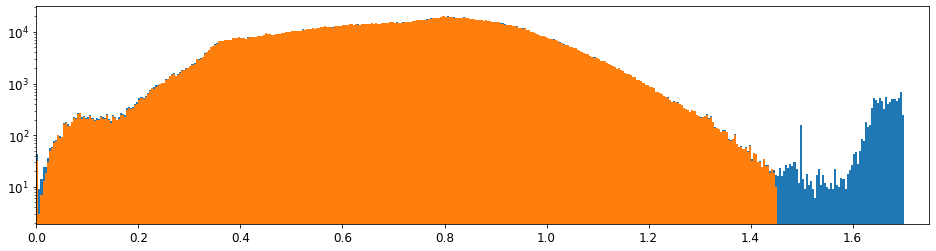

In [16]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'], 500, log=False, range=(0, 2.))
plt.hist(cat['Z'][mask_quality], 500, log=False, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

plt.figure(figsize=(16, 4))
plt.hist(cat['Z'], 500, log=True, range=(0, 2.))
plt.hist(cat['Z'][mask_quality], 500, log=True, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

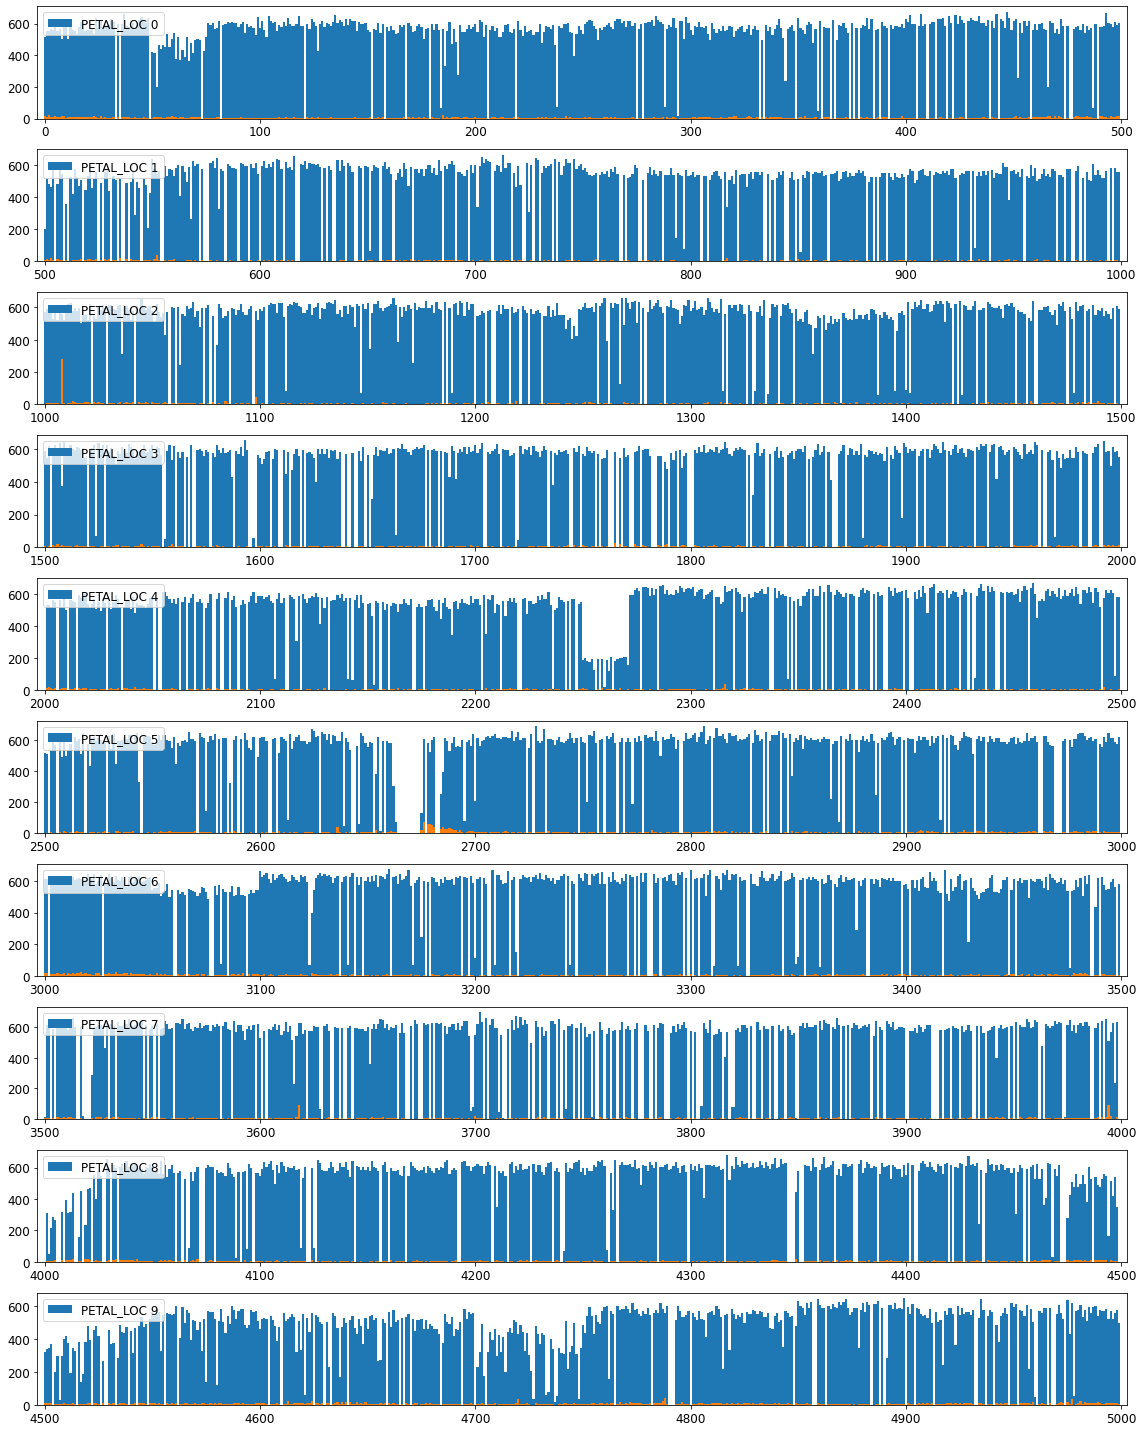

In [17]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-3, fiber_max+3)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [18]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats.sort('n_tot')

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~mask_quality], return_counts=True)
fiberstats = join(fiberstats, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats['frac_fail'] = fiberstats['n_fail']/fiberstats['n_tot']

error_floor = True

n, p = fiberstats['n_tot'].copy(), fiberstats['frac_fail'].copy()
if error_floor:
    p1 = np.maximum(p, 1/n)  # error floor
else:
    p1 = p
fiberstats['frac_fail_err'] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
fiberstats.sort('n_fail')

fiberstats

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
3986,3,0,0.0,0.2721655269759087
3726,494,0,0.0,0.0020222415820089186
1663,73,0,0.0,0.01360448036058687
4249,573,0,0.0,0.0017436771703362999
3349,74,0,0.0,0.013421895416371774
2143,66,0,0.0,0.015036292831784035
2141,72,0,0.0,0.013792101027561326
853,520,0,0.0,0.0019212269207986958
2345,70,0,0.0,0.014183306411342087


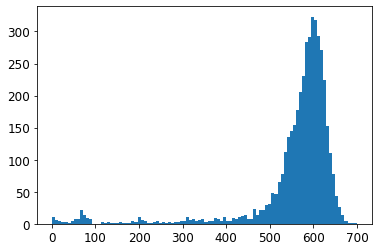

In [19]:
plt.hist(fiberstats['n_tot'], 100);

In [20]:
tmp = fiberstats.copy()
tmp.sort('frac_fail', reverse=True)
mask = tmp['n_tot']>min_fibers
tmp[mask][:30]

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
1008,560,282,0.5035714285714286,0.021128317359899753
3994,509,92,0.1807465618860511,0.01705631734001184
2675,130,22,0.16923076923076924,0.03288578322435809
3618,628,92,0.1464968152866242,0.014110319347836582
2679,525,62,0.1180952380952381,0.01408469299727745
2676,607,71,0.11696869851729819,0.01304453290422478
2678,580,61,0.10517241379310345,0.012738157256572276
2685,398,38,0.09547738693467336,0.014730532295389996
2684,254,24,0.09448818897637795,0.018353502864655622


In [21]:
fiberstats['MEAN_X'], fiberstats['MEAN_Y'] = 0., 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    mask = cat['FIBER']==fiber
    fiberstats['MEAN_X'][index], fiberstats['MEAN_Y'][index] = cat['MEAN_X'][mask][0], cat['MEAN_Y'][mask][0]

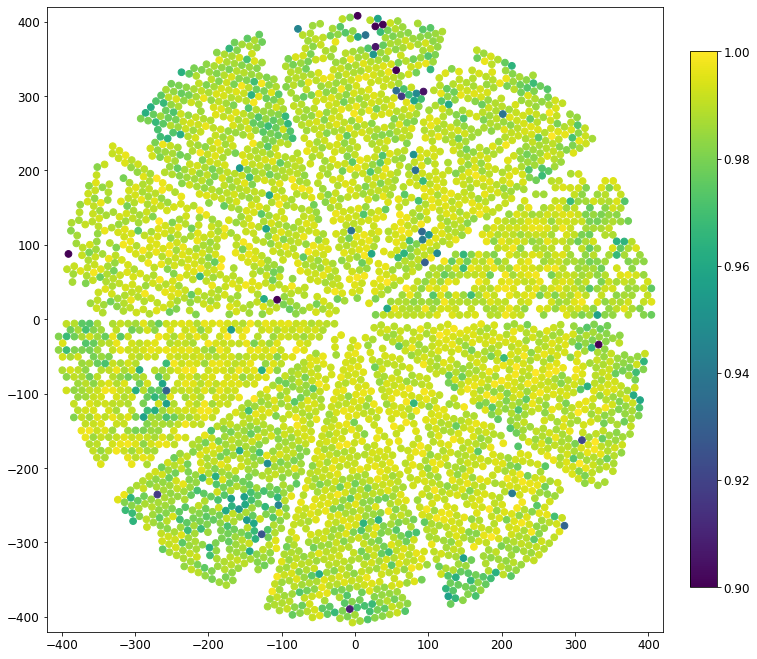

In [22]:
mask = fiberstats['n_tot']>min_fibers

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=45, vmin=0.9, vmax=1., cmap='viridis')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

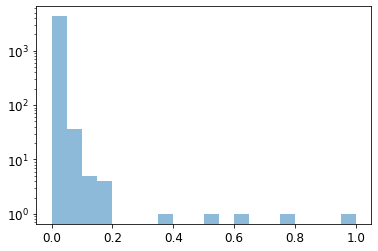

In [23]:
# mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers))
# mask_bad = (fiberstats['n_tot']>30) & np.in1d(fiberstats['FIBER'], bad_fibers)

# plt.hist(fiberstats['frac_fail'][mask_good], 20, range=(0, 0.4), log=True, alpha=0.5)
# plt.hist(fiberstats['frac_fail'][mask_bad], 20, range=(0, 0.4), log=True, alpha=0.5)
# plt.show()

plt.hist(fiberstats['frac_fail'], 20, log=True, alpha=0.5)
plt.show()

__Flag the worst fibers__

In [24]:
# frac_fail_threshold = np.percentile(fiberstats['frac_fail'], 99.5)
frac_fail_threshold = 0.05

print(frac_fail_threshold)
mask_threshold = fiberstats['frac_fail']>=frac_fail_threshold
print(np.sum(mask_threshold), np.sum(mask_threshold)/len(mask_threshold))
print(np.mean(fiberstats['frac_fail'][mask_threshold]), np.mean(fiberstats['frac_fail']), np.mean(fiberstats['frac_fail'][~mask_threshold]))
print(np.sum(fiberstats['n_fail'][mask_threshold])/np.sum(fiberstats['n_fail']))

bad_fibers = fiberstats['FIBER'][mask_threshold].copy()
print(len(bad_fibers))

0.05
50 0.011560693641618497
0.13870651775233775 0.01297019800155454 0.011499597770551227
0.04807251437237682
50


__Add statistical outliers__

In [25]:
mask = np.in1d(cat['FIBER'], bad_fibers)
print('Failure rate of bad fibers: {:.4f}%'.format(100*np.sum(mask_quality[mask])/np.sum(mask)))
mask = ~np.in1d(cat['FIBER'], bad_fibers)
print('Failure rate of good fibers: {:.4f}%'.format(100*np.sum(mask_quality[mask])/np.sum(mask)))

Failure rate of bad fibers: 89.6523%
Failure rate of good fibers: 98.8770%


In [26]:
mask = ~np.in1d(cat['FIBER'], bad_fibers)
average_success_rate = np.sum(mask_quality[mask])/np.sum(mask)
print(average_success_rate)

mask = fiberstats['n_tot']>min_fibers
mask &= fiberstats['frac_fail'] - 3.5*fiberstats['frac_fail_err'] > (1-average_success_rate)
print(np.sum(mask))
mask &= ~np.in1d(fiberstats['FIBER'], bad_fibers)
print(np.sum(mask))
fiberstats[mask]

0.9887698701315993
29
7


FIBER,n_tot,n_fail,frac_fail,frac_fail_err,MEAN_X,MEAN_Y
int32,int64,int64,float64,float64,float64,float64
4613,521,24,0.046065259117082535,0.009183901777619193,-147.6082000732422,-269.89111328125
2689,580,24,0.041379310344827586,0.008269914628693954,3.8759922981262207,379.3319396972656
3033,630,24,0.0380952380952381,0.00762660245245457,-278.507568359375,285.0037536621094
2686,615,25,0.04065040650406504,0.007963121395913016,80.51358795166016,293.72332763671875
1765,583,25,0.04288164665523156,0.008390431027202511,330.335205078125,5.669180870056152
2687,596,25,0.04194630872483222,0.008211427614720889,31.00221061706543,403.9146423339844
4624,558,26,0.04659498207885305,0.008922595227759178,-158.33155822753906,-255.19039916992188


In [40]:
bad_fibers = np.unique(np.concatenate([fiberstats['FIBER'][mask], bad_fibers]))
print('Total number of bad fibers:', len(bad_fibers))
print(bad_fibers)

Total number of bad fibers: 57
[ 466  552  651  817 1008 1098 1400 1597 1765 1969 2250 2259 2260 2261
 2267 2271 2316 2575 2628 2636 2654 2663 2675 2676 2678 2679 2680 2681
 2684 2685 2686 2687 2688 2689 3033 3082 3476 3500 3546 3618 3754 3849
 3974 3994 4002 4019 4089 4507 4613 4621 4624 4720 4733 4748 4788 4957
 4977]


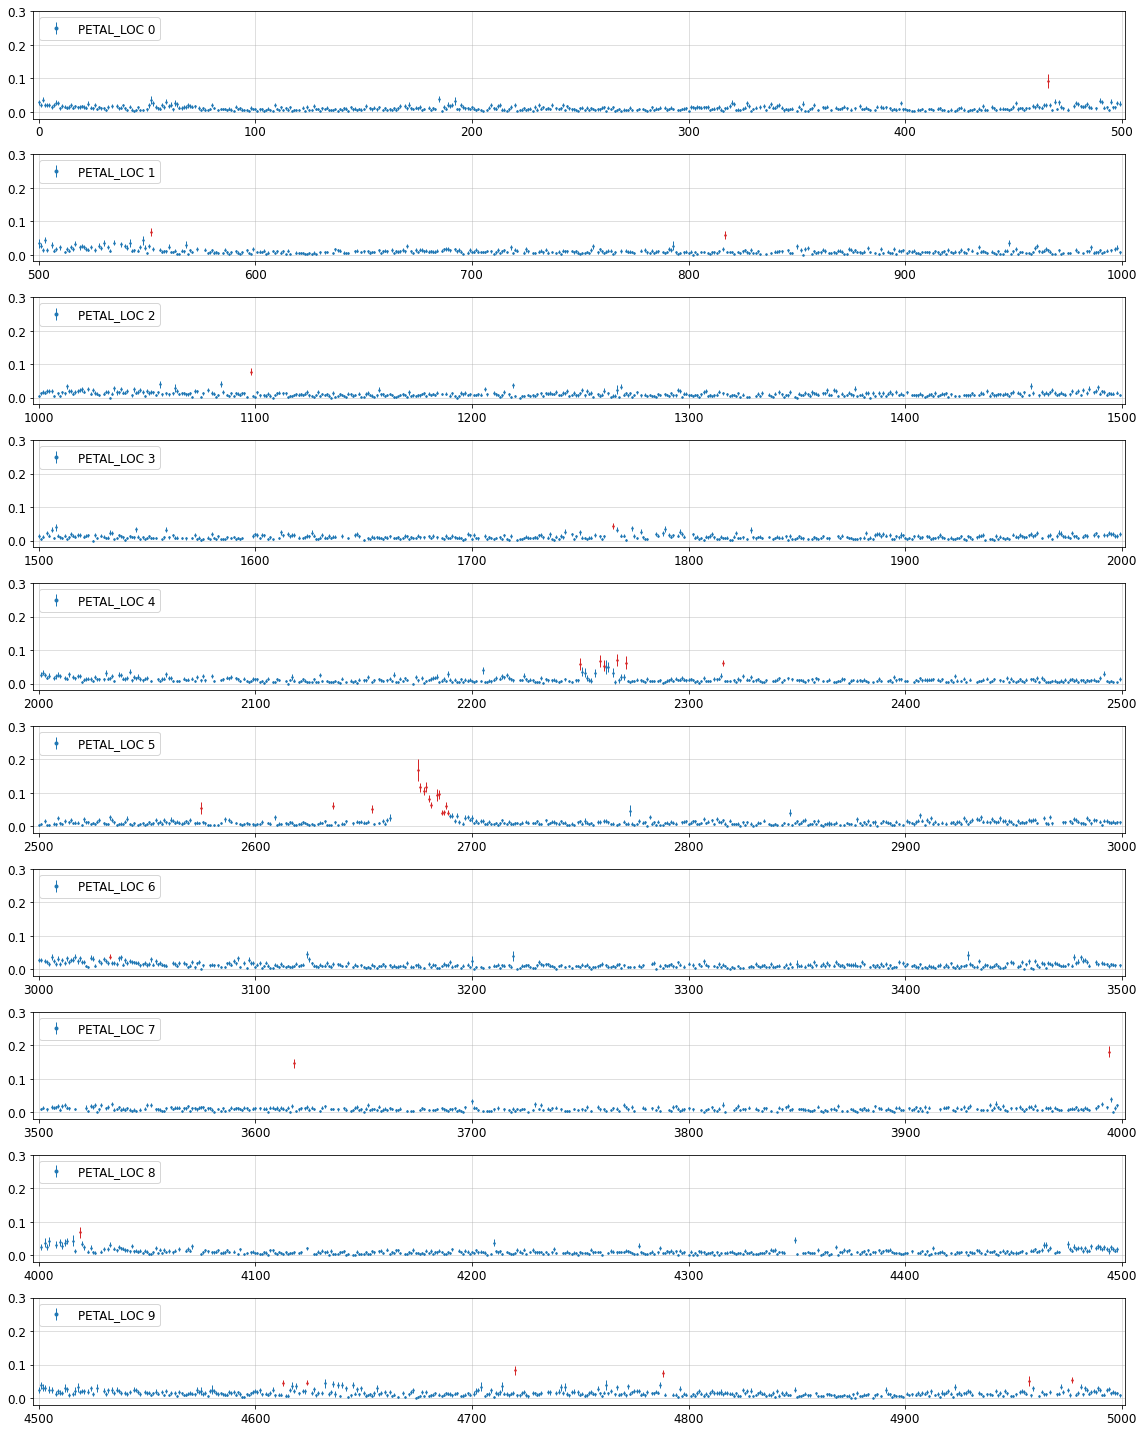

In [28]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (fiberstats['FIBER']>fiber_min) & (fiberstats['FIBER']<fiber_max)
    mask &= (fiberstats['n_tot']>min_fibers)
    mask_good = mask & (~np.in1d(fiberstats['FIBER'], bad_fibers))
    mask_bad = mask & np.in1d(fiberstats['FIBER'], bad_fibers)
    # plt.figure(figsize=(16, 2))
    ax[index].errorbar(fiberstats['FIBER'][mask_good], fiberstats['frac_fail'][mask_good], 
                       yerr=(np.clip(fiberstats['frac_fail_err'][mask_good], None, fiberstats['frac_fail'][mask_good]), fiberstats['frac_fail_err'][mask_good]),
                       color='C0', fmt='.', ms=3, elinewidth=1, label='PETAL_LOC {}'.format(index))
    ax[index].errorbar(fiberstats['FIBER'][mask_bad], fiberstats['frac_fail'][mask_bad],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad], None, fiberstats['frac_fail'][mask_bad]), fiberstats['frac_fail_err'][mask_bad]),
                   color='C3', fmt='.', ms=3, elinewidth=1)
    ax[index].grid(alpha=0.5)
    ax[index].set_yticks([0., 0.1, 0.2, 0.3], minor=False)
    ax[index].set_ylim(-0.02, 0.3)
    ax[index].set_xlim(fiber_min-2, fiber_max+2)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

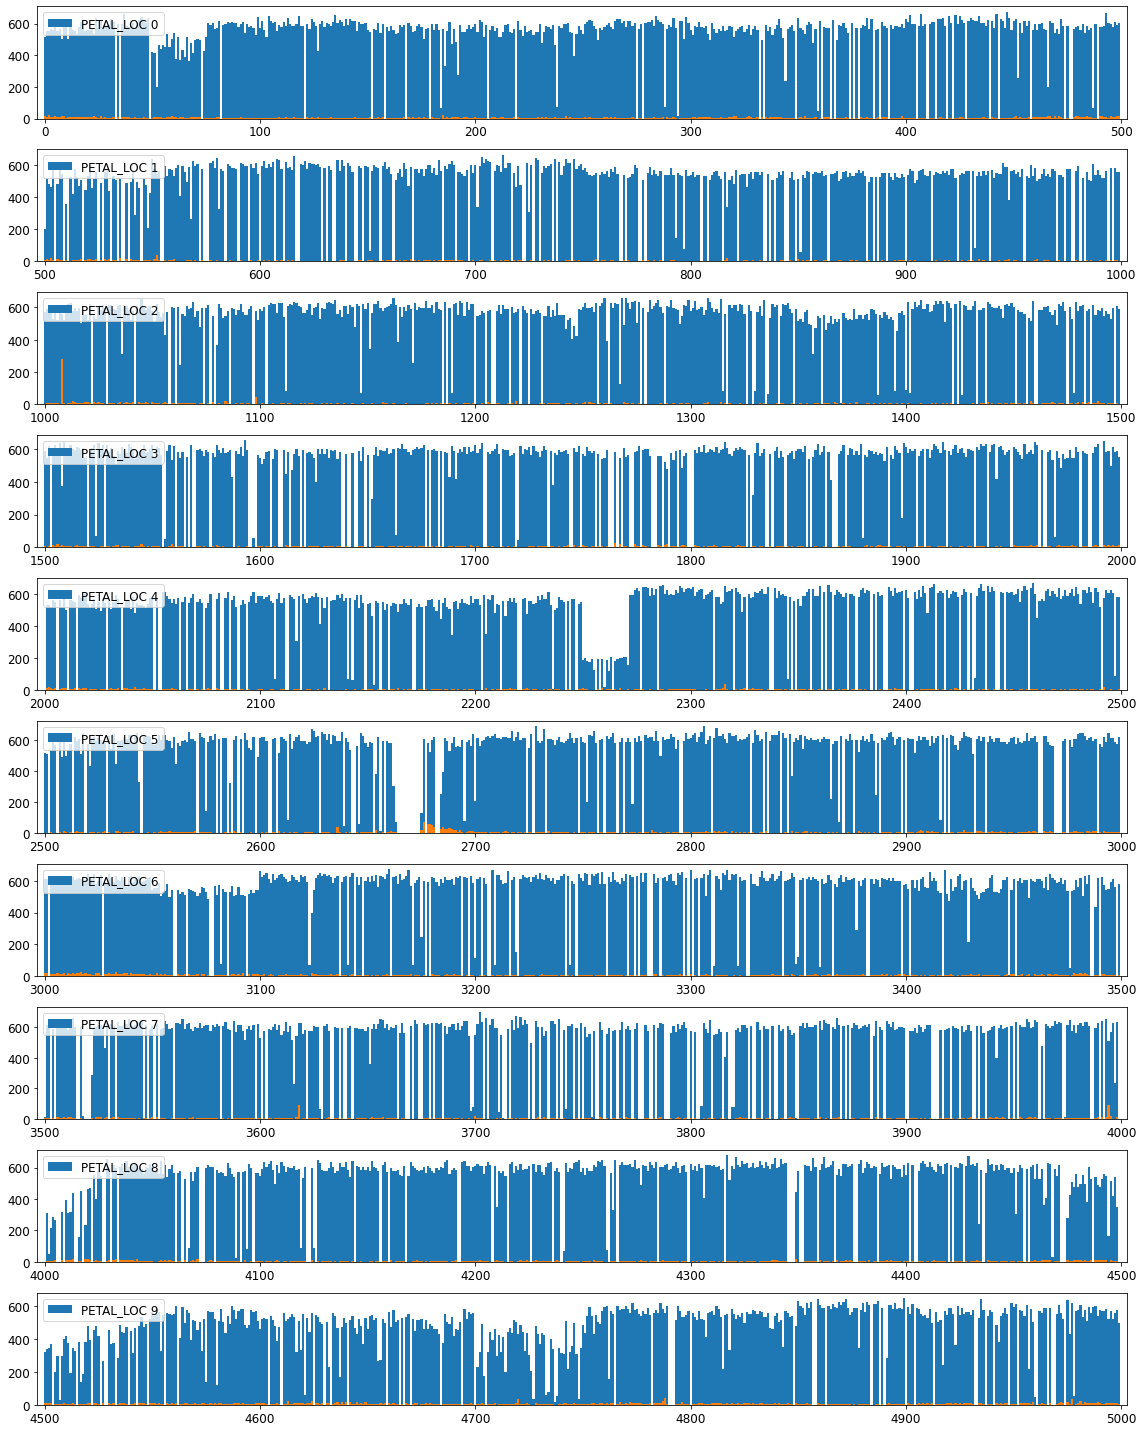

In [29]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    # mask &= (~np.in1d(cat['FIBER'], bad_fibers))
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-3, fiber_max+3)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

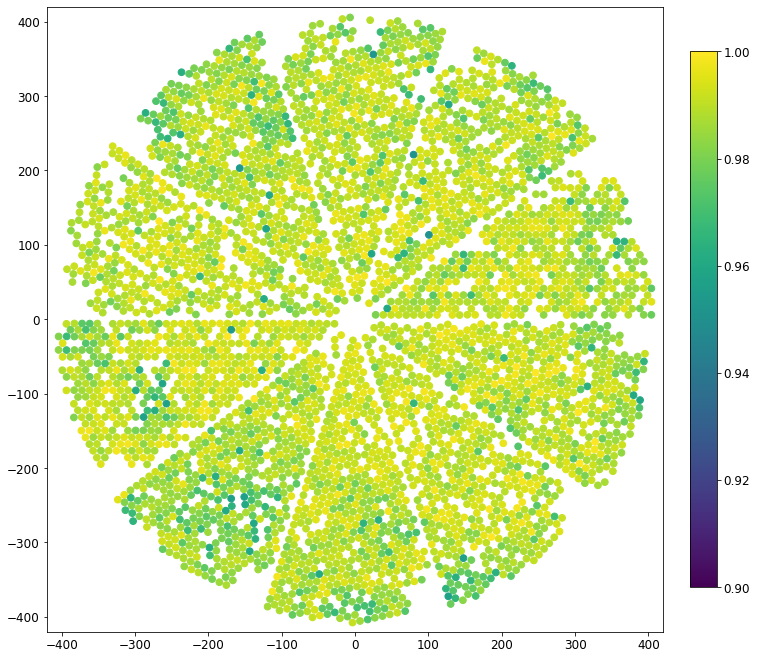

In [30]:
mask = fiberstats['n_tot']>min_fibers
mask &= (~np.in1d(fiberstats['FIBER'], bad_fibers))

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=45, vmin=0.9, vmax=1., cmap='viridis')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

In [31]:
np.savetxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_himalayas_20230106.txt', bad_fibers, fmt='%s')

In [37]:
mask = np.in1d(cat['FIBER'], bad_fibers)
print('Failure rate in \"good\" fibers: {:.2f}%'.format(100*np.sum(~cat['q'][~mask])/np.sum(~mask)))
print('Failure rate in \"bad\" fibers: {:.2f}%'.format(100*np.sum(~cat['q'][mask])/np.sum(mask)))

Failure rate in "good" fibers: 1.12%
Failure rate in "bad" fibers: 8.90%
